In [1]:
import json
import pandas as pd
import numpy as np

countries = ["United States", "India", "Pakistan", "Nigeria", "Philippines", "United Kingdom", "Germany", "Uganda", "Canada", "Egypt", "France", "Australia"]
vis_countries = ["US", "India", "Pakistan", "Nigeria", "Philippines", "UK", "Germany", "Uganda", "Canada", "Egypt", "France", "Australia"]

topics = ["Politics", "Social Networks", "Social Inequality", "Family & Changing Gender Roles", "Work Orientation", "Religion", "Environment", "National Identity", "Citizenship", "Leisure Time and Sports", "Health and Health Care"]
vis_topics = ["Politics", "SocialNet", "Inequality", "Family", "Work", "Religion", "Environment", "Identity", "Citizenship", "Leisure", "Health"]


schwartz_values = {
    "Power": ["Social Power", "Authority", "Wealth", "Preserving my Public Image", "Social Recognition"],
    "Achievement": ["Successful", "Capable", "Ambitious", "Influential", "Intelligent", "Self-Respect"],
    "Hedonism": ["Pleasure", "Enjoying Life"],
    "Stimulation": ["Daring", "A Varied Life", "An Exciting Life"],
    "Self-direction": ["Creativity", "Curious", "Freedom", "Choosing Own Goals", "Independent"],
    "Universalism": ["Protecting the Environment", "A World of Beauty", "Broad-Minded", "Social Justice", "Wisdom", "Equality", "A World at Peace", "Inner Harmony", "Unity With Nature"],
    "Benevolence": ["Helpful", "Honest", "Forgiving", "Loyal", "Responsible", "True Friendship", "A Spiritual Life", "Mature Love", "Meaning in Life"],
    "Tradition": ["Devout", "Accepting my Portion in Life", "Humble", "Moderate", "Respect for Tradition", "Detachment"],
    "Conformity": ["Politeness", "Honoring of Parents and Elders", "Obedient", "Self-Discipline"],
    "Security": ["Clean", "National Security", "Social Order", "Family Security", "Reciprocation of Favors", "Healthy", "Sense of Belonging"]
}

def get_value_list(schwartz_values):
    value_list = []
    for key, value in schwartz_values.items():
        value_list.extend([f"{value}" for value in value])
    return value_list
value_list = get_value_list(schwartz_values)
print(len(value_list))

def get_scenario_list(countries, topics):
    scenarios_list = []
    for country in countries:
        for topic in topics:
            scenarios_list.append(f"{country}+{topic}")
    return scenarios_list
scenarios_list = get_scenario_list(countries, topics)
print(len(scenarios_list))



56
132


In [11]:
# Data file directories
task1_input = "../../../results/task1/config1_results.csv"
task2_input = "../../../results/task2/final_config1_full_results.csv"
figure_output_dir = "../../../outputs/figures/itcvs/config1_full/"

In [2]:
# Load data
def clean_generation(response: str) -> str:
    """Extract the task1's results in json format."""
    if "```" in response:
        sub1 = "```json"
        sub2 = "```"
        response = ''.join(response.split(sub1)[1].split(sub2)[0])
        return response
    else:
        return response

def clean_generation_without_json(response: str) -> str:
    """Extract the task1's results in json format."""
    if "```" in response:
        sub1 = "```"
        sub2 = "```"
        response = ''.join(response.split(sub1)[1].split(sub2)[0])
        return response
    else:
        return response


def clean_value_response(response: str) -> str:
    """Replaces the response that only reply string without number. Rules are:
       1: very much like me, 2: like me, 3: not like me, 4: Not like me at all """
    response = response.lower().replace("not like me at all", "4").replace("not like me", "3").replace("very much like me", "1").replace("like me", "2")
    return response


def generate_full_t1_table(t1_measures: pd.DataFrame, value_list: list) -> list[list]:
    """Parses the task1's results into dataframe."""
    full_t1_table_pd = []
    for index, row in t1_measures.iterrows():
        country = row['country']
        topic   = row['topic']
        prompt_index = row['prompt_index']
        try:
            response = json.loads(clean_generation(row['response']))
        except Exception as e:
            try:
                response = json.loads(clean_generation_without_json(row['response']))
            except Exception as e:
                continue
        value_response_list = []
        for value in value_list:
            try:
                if value in response.keys():
                    value_response_list.append(int(clean_value_response(response[value])[0]))
            except Exception as e:
                continue

        pd_row = [country, topic, prompt_index] + value_response_list
        full_t1_table_pd.append(pd_row)
    return full_t1_table_pd

In [3]:
def generate_full_t2_table(t2_measures: pd.DataFrame, value_list: list, model: str = None) -> pd.DataFrame:
    """Parses the task2's results into dataframe."""
    full_value_dict = {}
    for index, row in t2_measures.iterrows():
        if row['model_choice'] == True:
            country = row['country']
            topic   = row['topic']
            prompt_index = row['prompt_index']
            key = f"{country}+{topic}+{prompt_index}"
            value = row['value']
            if model == 'gpt4o-mini':
                polarity = 1 if row['polarity'] == 'positive' else 0 ### GPT4o-mini saved the flipped reponses 
            else:
                polarity = 0 if row['polarity'] == 'positive' else 1

            if key in full_value_dict.keys():
                full_value_dict[key][value] = polarity
            else:
                full_value_dict[key] = {value: polarity}

    ### Get the full dictionary
    full_t2_table_pd = []
    for key, value_dict in full_value_dict.items():
        country, topic, prompt_index = key.split('+')
        value_response_list = [int(value_dict[value]) if value in value_dict.keys() else 0 for value in value_list]
        pd_row = [country, topic, prompt_index] + value_response_list
        full_t2_table_pd.append(pd_row)
    return full_t2_table_pd


### Data Processing Steps:
- Step1: Average the Prompt Indexes;
- Step2: Normalize the responses;
- Step3: Convert into Matrix; 
- Step4: Group the responses (if applicable);

In [4]:
def min_max_normalization(matrix: np.array, min=None, max=None):
    if not min:
        min = np.min(matrix)
    if not max:
        max = np.max(matrix)
    # print(f"min={min}, max={max}")
    new_matrix = (matrix - min) / (max - min)
    return new_matrix

def average_normalized_pd_matrix(response_pd: pd.DataFrame, scenarios_list: list, value_list: list, task: int):
    full_pd, full_matrix = [], []
    for scenario in scenarios_list:
        country, topic = scenario.split('+')

        ### Average the score of eight prompts.
        average_prompting = response_pd[(response_pd['country'] == country) & (response_pd['topic'] == topic )].iloc[:,3:].mean()
        
        ### Step: Normalize the responses
        normalized_average_prompting = min_max_normalization(np.array(list(average_prompting)), 1, 4) if task == 1 else min_max_normalization(np.array(list(average_prompting)), 0, 1)

        ### Save normalized Matrix
        full_matrix.append(normalized_average_prompting)
        
        ### Save normalized DataFrame
        full_pd.append([country, topic] + list(normalized_average_prompting))
    full_pd_all = pd.DataFrame(full_pd, columns=['country', 'topic'] + [f"{value}" for value in value_list])
    return full_pd_all, np.array(full_matrix)


def grouping_country_matrix(full_pd: pd.DataFrame, scenario_list: list, scenario_name: str, starting_idx: int = 2) -> pd.DataFrame:
    grouping_country = []
    for item in scenario_list:
        average_scenarios = full_pd[(full_pd[scenario_name] == item)].iloc[:,starting_idx:].mean()
        grouping_country.append(list(average_scenarios))
    results = pd.DataFrame(grouping_country, columns=[f"{value}" for value in value_list])
    return results.to_numpy()


### Load Models's Results

In [12]:
model_name = "llama3"

### Task1
t1_measures = pd.read_csv(task1_input)
full_t1_responses = pd.DataFrame(generate_full_t1_table(t1_measures, value_list), 
                                                        columns=['country', 'topic', 'prompt_index'] + [f"value_{value}" for value in value_list])
t1_pd, t1_matrix = average_normalized_pd_matrix(full_t1_responses, scenarios_list, value_list, 1)

### Task2
t2_measures = pd.read_csv(task2_input)
full_t2_responses = pd.DataFrame(generate_full_t2_table(t2_measures, value_list, "llama"), 
                                                        columns=['country', 'topic', 'prompt_index'] + [f"value_{value}" for value in value_list])
t2_pd, t2_matrix = average_normalized_pd_matrix(full_t2_responses, scenarios_list, value_list, 2)

In [13]:
t1_measures.head()

,Unnamed: 0,country,topic,prompt_index,response
0,0,United States,Politics,0,"{""Equality"": ""2"", ""Inner Harmony"": ""2"", ""Socia..."
1,1,United States,Politics,1,"{""Equality"": ""2"", ""Inner Harmony"": ""2"", ""Socia..."
2,2,United States,Politics,2,"{""Equality"": ""1"", ""Inner Harmony"": ""1"", ""Socia..."
3,3,United States,Politics,3,"{""Equality"": ""2"", ""Inner Harmony"": ""2"", ""Socia..."
4,4,United States,Politics,4,"{""Equality"": ""2"", ""Inner Harmony"": ""2"", ""Socia..."


In [14]:
full_t1_responses.head()

,country,topic,prompt_index,value_Social Power,value_Authority,value_Wealth,value_Preserving my Public Image,value_Social Recognition,value_Successful,value_Capable,...,value_Honoring of Parents and Elders,value_Obedient,value_Self-Discipline,value_Clean,value_National Security,value_Social Order,value_Family Security,value_Reciprocation of Favors,value_Healthy,value_Sense of Belonging


In [10]:
full_t2_responses.head()

,country,topic,prompt_index,value_Social Power,value_Authority,value_Wealth,value_Preserving my Public Image,value_Social Recognition,value_Successful,value_Capable,...,value_Honoring of Parents and Elders,value_Obedient,value_Self-Discipline,value_Clean,value_National Security,value_Social Order,value_Family Security,value_Reciprocation of Favors,value_Healthy,value_Sense of Belonging
0,Australia,Citizenship,0,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Australia,Citizenship,1,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Australia,Citizenship,2,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Australia,Citizenship,3,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Australia,Citizenship,4,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
response_pd = full_t1_responses.replace(1, 0).replace(2, 0)
response_pd = response_pd.replace(3, 1).replace(4, 1)

all_agreement = []
all_agree_count = []
for scenario in scenarios_list:
    country, topic = scenario.split('+')

    ### Average the score of eight prompts.
    average_prompting = response_pd[(response_pd['country'] == country) & (response_pd['topic'] == topic )].iloc[:,3:]
    agreement = average_prompting.apply(lambda col: (col == col.mode()[0]).mean())

    # print(average_prompting)
    # print(agreement)
    # print("agreement add", len(np.where(agreement == 1)[0]))
    all_agree_count.append(len(np.where(agreement == 1)[0]))
    # print("average", agreement.mean())
    all_agreement.append(agreement.mean())
    
print("agree1", np.array(all_agreement).mean())
print("agree12", np.array(all_agree_count).mean())

agree1 nan
agree12 0.0


#### Grouped Scenarios;

In [9]:
t1_grouped_country_values = grouping_country_matrix(t1_pd, countries, 'country')
t1_grouped_topic_values = grouping_country_matrix(t1_pd, topics, 'topic')
t2_grouped_country_values = grouping_country_matrix(t2_pd, countries, 'country')
t2_grouped_topic_values = grouping_country_matrix(t2_pd, topics, 'topic')

### Start Analysis

We will analyze the results of Task1 and Task2 with respect to a number of alignment measures, which includes:

- 0. Raw Responses;
- 1. Alignment Rates;
- 2. Alignment Distance;
- 3. Rankings;
- 4. Explanation


Figure + Tables:
-------------------------------------
- 1. Heatmaps;
- 2. Table Rate Scores;
- 3. Ranking Figures;
-------------------------------------
- 4. Explanation (Another Notebook)


##### (1) Heatmaps

In [32]:
import numpy as np
from scipy.spatial.distance import cdist

class AlignmentMeasures:
    """This class implements the Alignment Distance and Ranking measures."""
    def __init__(self, value_list: list, scenarios_list: list):
        self.value_list = value_list
        self.scenarios_list = scenarios_list

    def manhattan_distance(self, t1_matrix, t2_matrix):
        return np.abs(t1_matrix - t2_matrix)

    def euclidean_distance(self, t1_matrix, t2_matrix):
        diff = t1_matrix - t2_matrix
        return np.einsum('ij,ij->ij', diff, diff)

    def distance_ranking(self, difference_matrix, axis=1):
        """Sort the values along the scenarios;
        """
        sorted_list = np.sort(difference_matrix, axis=axis)[:,::-1]
        sorted_list_idx = np.argsort(difference_matrix, axis=axis)[:,::-1]
        sorted_values = np.array([[self.value_list[idx] for idx in row] for row in sorted_list_idx])
        return sorted_list, sorted_list_idx, sorted_values


In [33]:
from string import ascii_letters
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import matplotlib
matplotlib.font_manager.get_font_names()

def heatmap_visualization(matrix: list[list], x_axis_labels: list, y_axis_labels: list, figsize: tuple, save_path: str = None, vmax: float = None):
    sns.set_theme(style="white")

    # Set up the matplotlib figure
    f, ax = plt.subplots(figsize=figsize)

    # Generate a custom diverging colormap
    cmap = sns.diverging_palette(230, 20, as_cmap=True)

    # Draw the heatmap with the mask and correct aspect ratio
    # sns.heatmap(corr,  cmap=cmap, vmax=.3, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .5})
    if vmax:
        hm = sns.heatmap(matrix,  cmap=cmap, vmax=vmax, square=True, cbar_kws={"shrink": .18, "pad": 0.01},  linewidths=.5, xticklabels=x_axis_labels, yticklabels=y_axis_labels)
    else:
        hm = sns.heatmap(matrix,  cmap=cmap, square=True, cbar_kws={"shrink": .18, "pad": 0.01},  linewidths=.5, xticklabels=x_axis_labels, yticklabels=y_axis_labels)
    
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, fontfamily='sans-serif', color='black')
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=12, fontfamily='sans-serif', color='black')

    # Style the colorbar labels
    cbar = hm.collections[0].colorbar
    cbar.ax.tick_params(labelsize=12)
    cbar.ax.set_yticklabels(cbar.ax.get_yticklabels(), 
                           fontfamily='sans-serif',
                           color='black')

    # Save figure if path is provided
    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)
        

In [34]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_ranking(ranked_distance, ranked_values, x_label='Value Rankings', y_label='Alignment Distance', title='United Kindom', saved_path = "../../outputs/figures/ranking_uk.pdf"):

    sns.set_theme(style="white", context="talk")

    # Set up the matplotlib figure
    f, ax = plt.subplots(1, 1, figsize=(15, 5), sharex=True)

    sns.barplot(x=ranked_values, y=ranked_distance, palette="rocket", ax=ax)

    ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, fontfamily='sans-serif', color='black', rotation=45, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=12, fontfamily='sans-serif', color='black', rotation=45, ha='right')
    ax.spines[['right', 'top']].set_visible(False)

    ax.set_xlabel(x_label, fontsize=14, fontfamily='sans-serif', color='black')
    ax.set_ylabel(y_label, fontsize=14, fontfamily='sans-serif', color='black')
    ax.set_title(title, fontsize=14, fontfamily='sans-serif', color='black')

    plt.tight_layout(h_pad=2)
    plt.savefig(saved_path, format='pdf', bbox_inches='tight', dpi=300)

In [35]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

**Alignment Distance**

In [36]:
align_measure = AlignmentMeasures(value_list, scenarios_list)
distance_country = align_measure.manhattan_distance(t1_grouped_country_values, t2_grouped_country_values)
distance_topic = align_measure.manhattan_distance(t1_grouped_topic_values, t2_grouped_topic_values)

**Rank the values**

In [37]:
align_measure = AlignmentMeasures(value_list, scenarios_list)
ranked_distance_country, ranked_distance_idx_country, rank_value_list_country = align_measure.distance_ranking(distance_country)
ranked_distance_topic, ranked_distance_idx_topic, rank_value_list_topic = align_measure.distance_ranking(distance_topic)

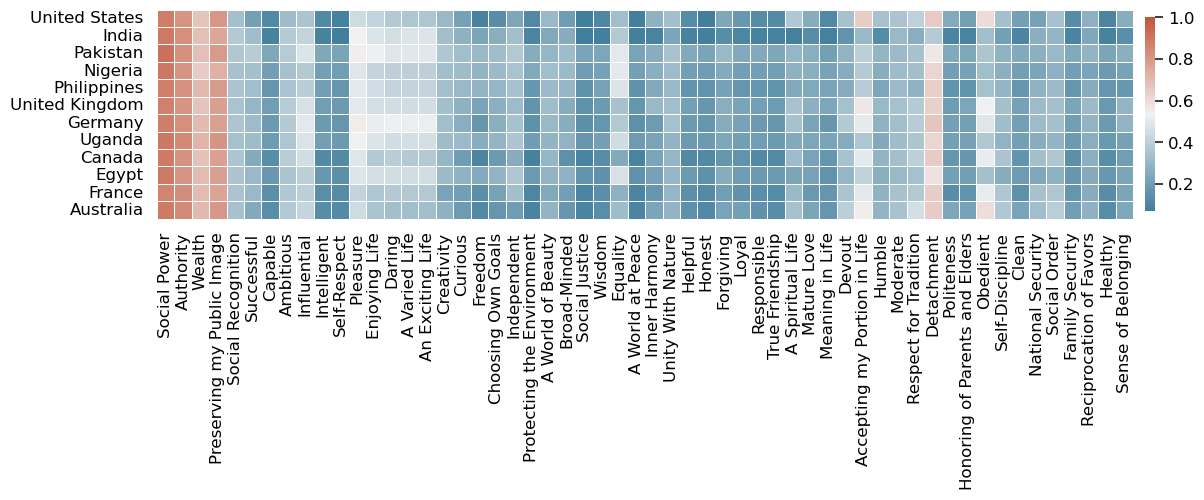

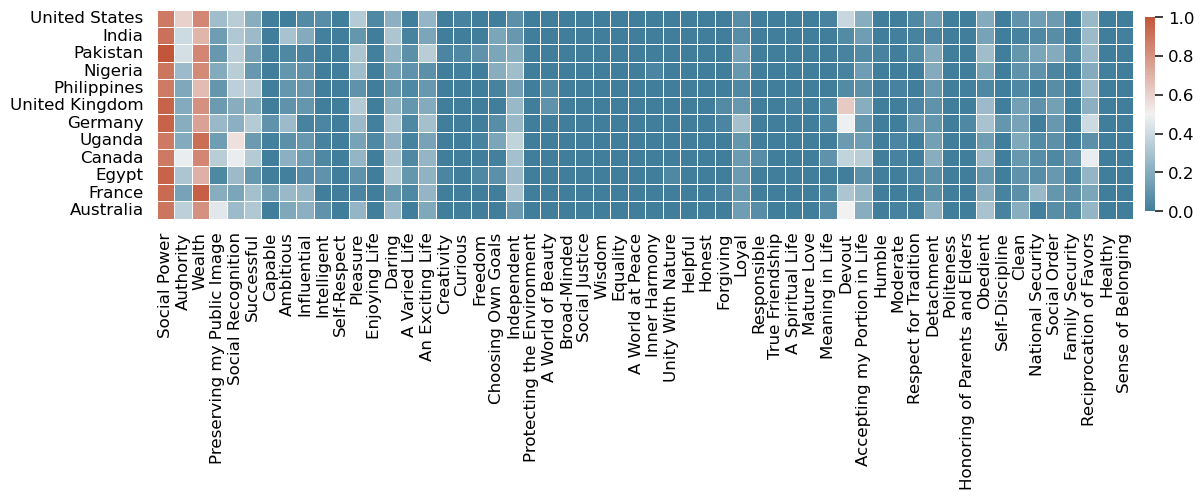

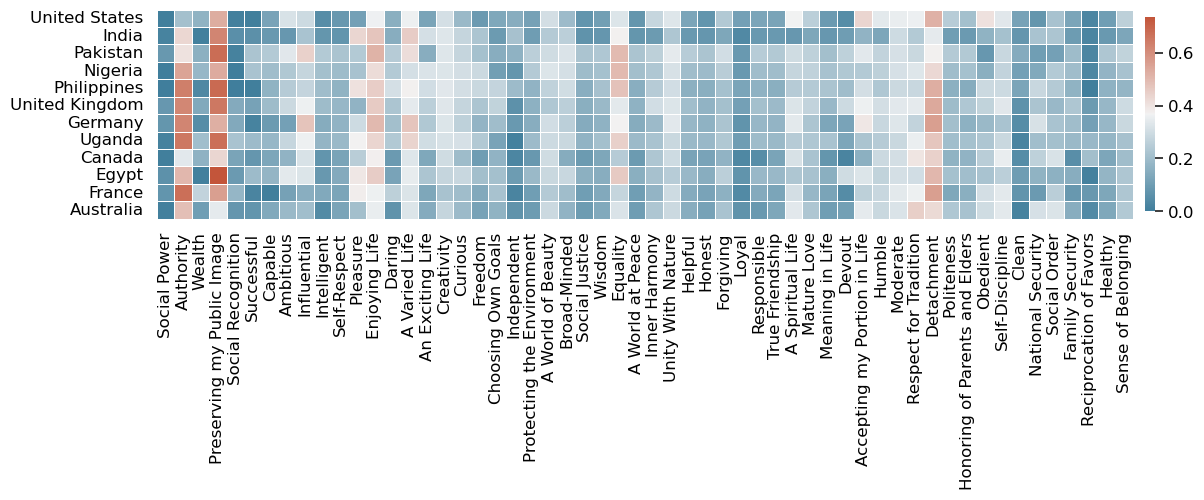

In [38]:
figsize = (15, 14)
heatmap_visualization(t1_grouped_country_values, value_list, countries, figsize, f"../../../outputs/figures/itcvs/config0_full/t1_country_{model_name}.pdf", vmax=1.)
figsize = (15, 14)
heatmap_visualization(t2_grouped_country_values, value_list, countries, figsize,  f"../../../outputs/figures/itcvs/config0_full/t2_country_{model_name}.pdf", vmax=1.)
figsize = (15, 14)
heatmap_visualization(distance_country, value_list, countries, figsize, f"../../../outputs/figures/itcvs/config0_full/distance_manhattan_country_{model_name}.pdf")

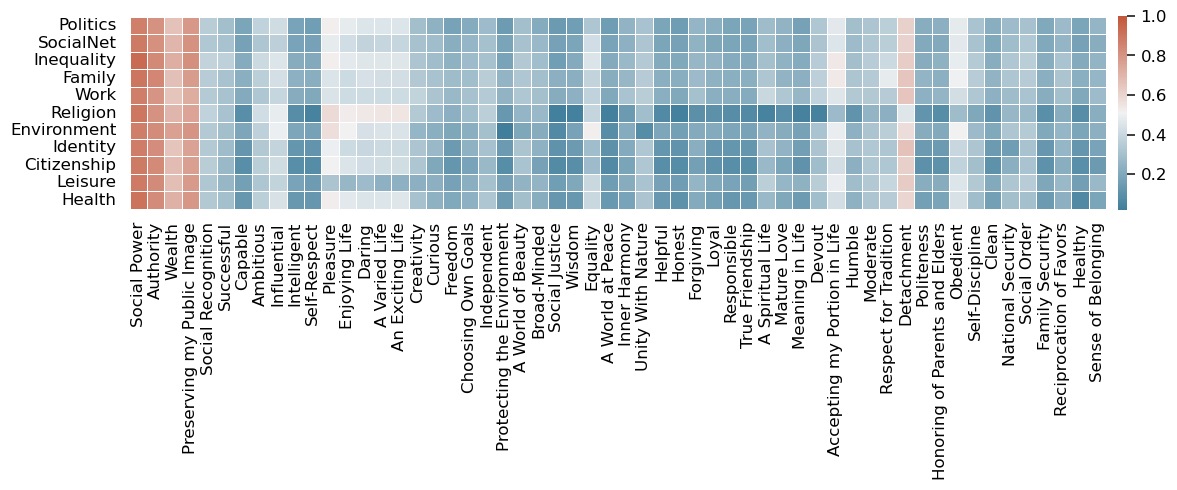

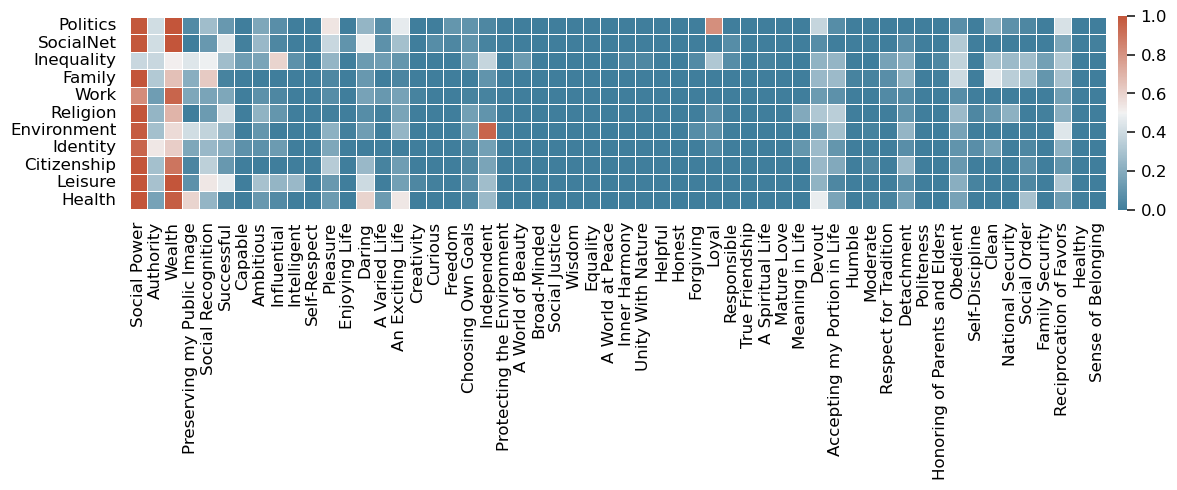

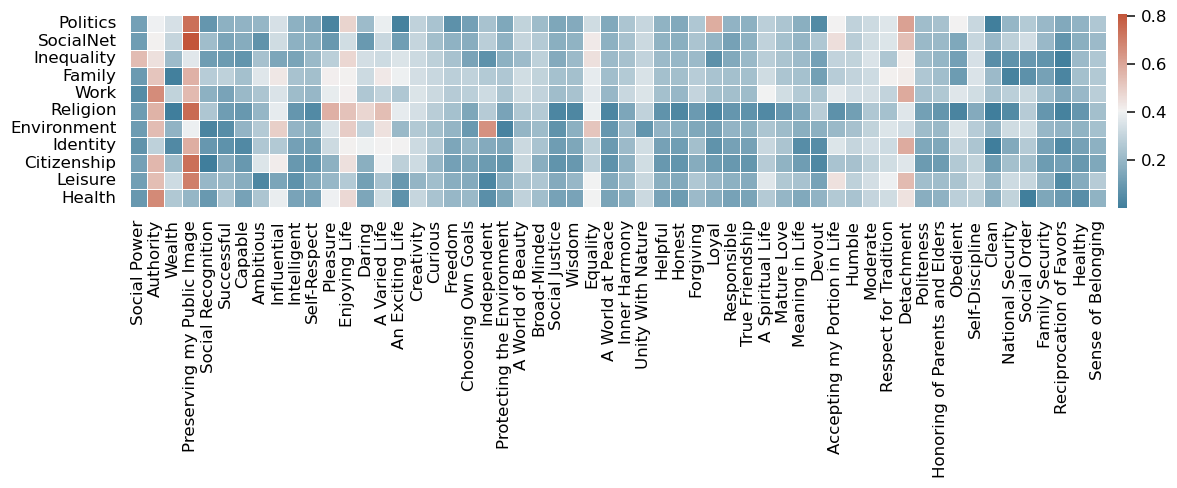

In [39]:
figsize = (15, 14)
heatmap_visualization(t1_grouped_topic_values, value_list, vis_topics, figsize, f"../../../outputs/figures/itcvs/config0_full/t1_value_{model_name}.pdf", vmax=1.)
figsize = (15, 14)
heatmap_visualization(t2_grouped_topic_values, value_list, vis_topics, figsize, f"../../../outputs/figures/itcvs/config0_full/t2_value_{model_name}.pdf", vmax=1.)
figsize = (15, 14)
heatmap_visualization(distance_topic, value_list, vis_topics, figsize, f"../../../outputs/figures/itcvs/config0_full/distance_manhattan_topic_{model_name}.pdf")

/w0/tmp/slurm_zs473554.65278993/ipykernel_314955/1664519472.py:10: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  f, ax = plt.subplots(1, 1, figsize=(15, 5), sharex=True)


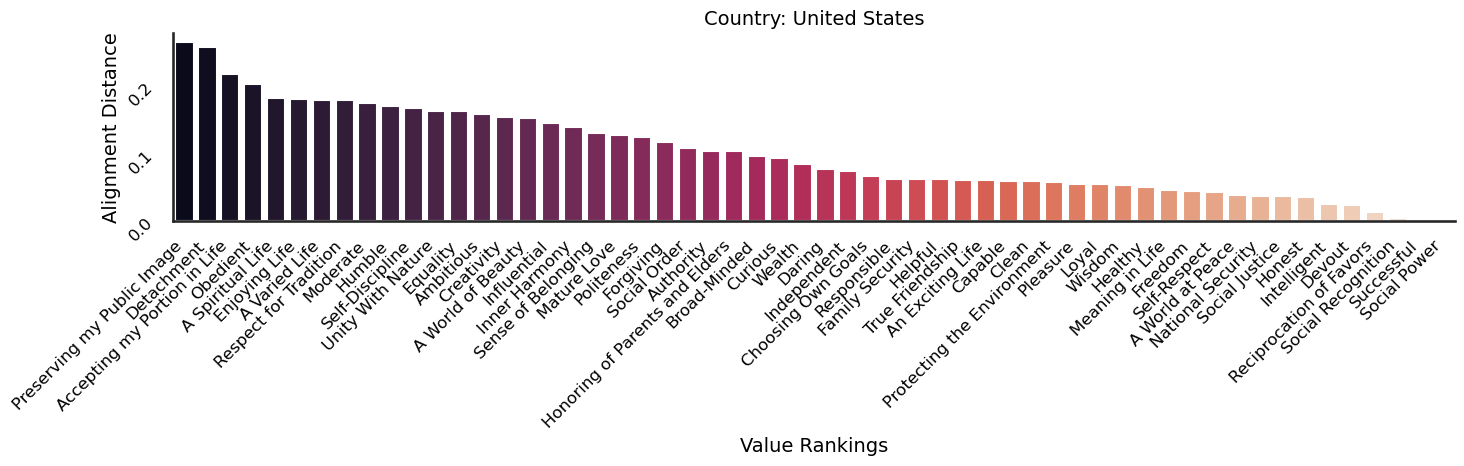

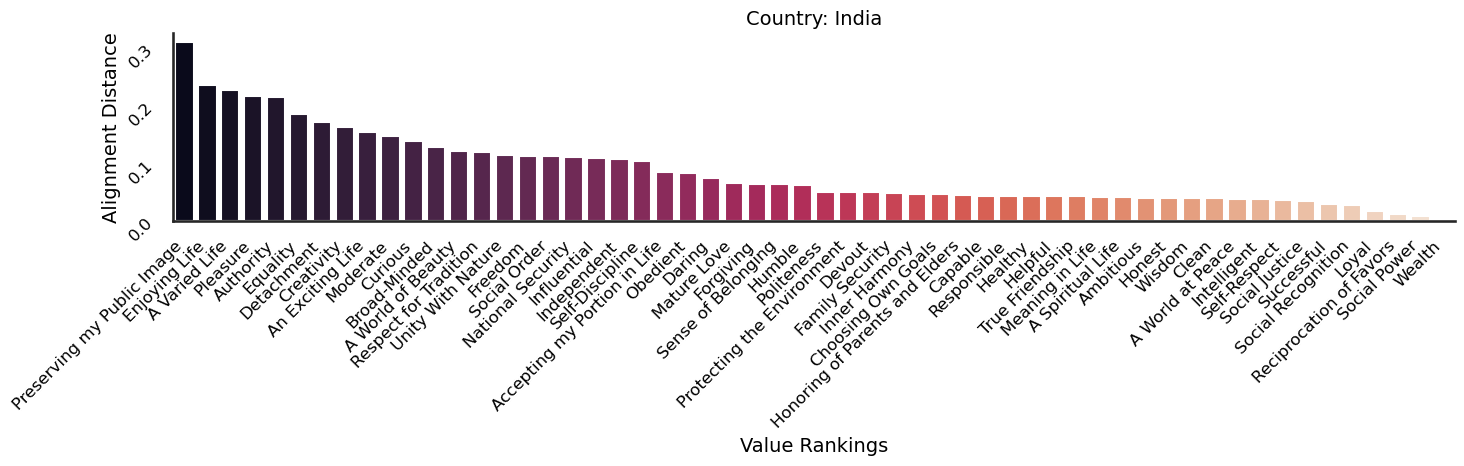

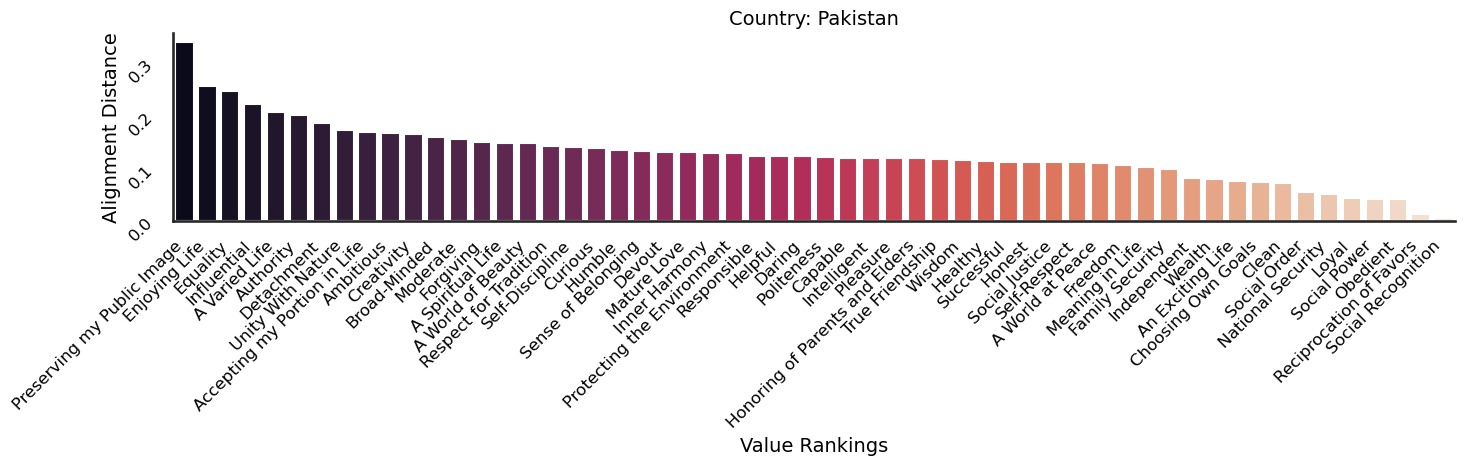

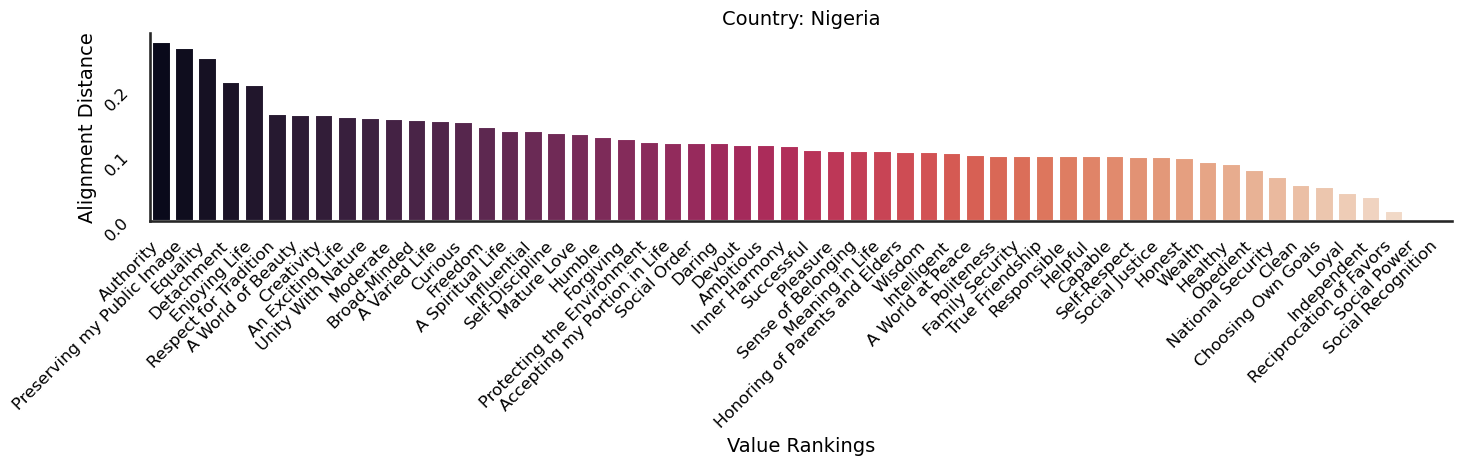

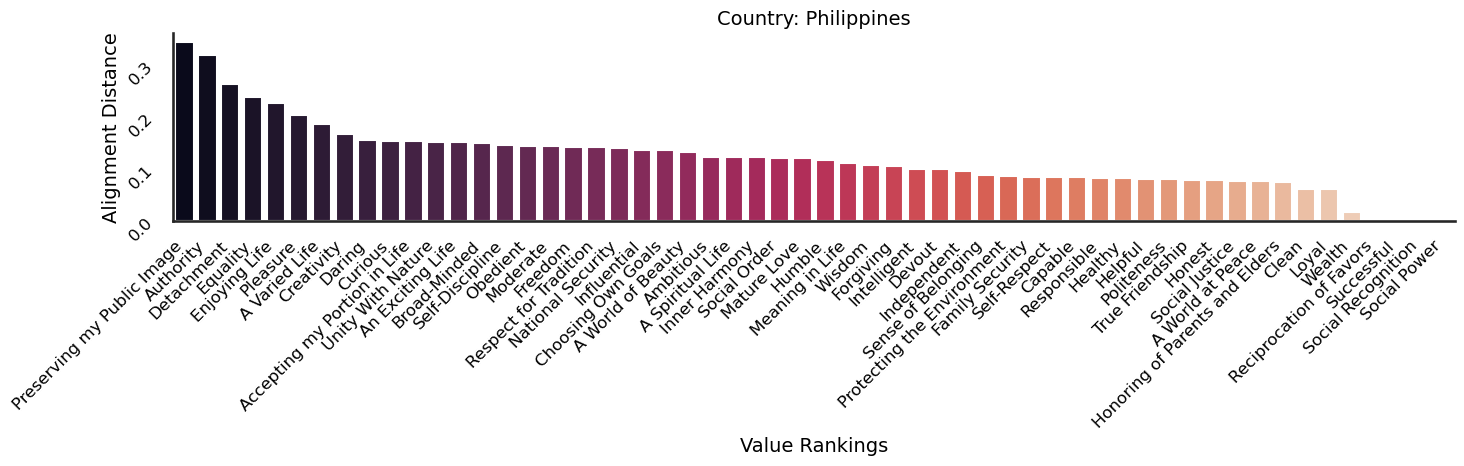

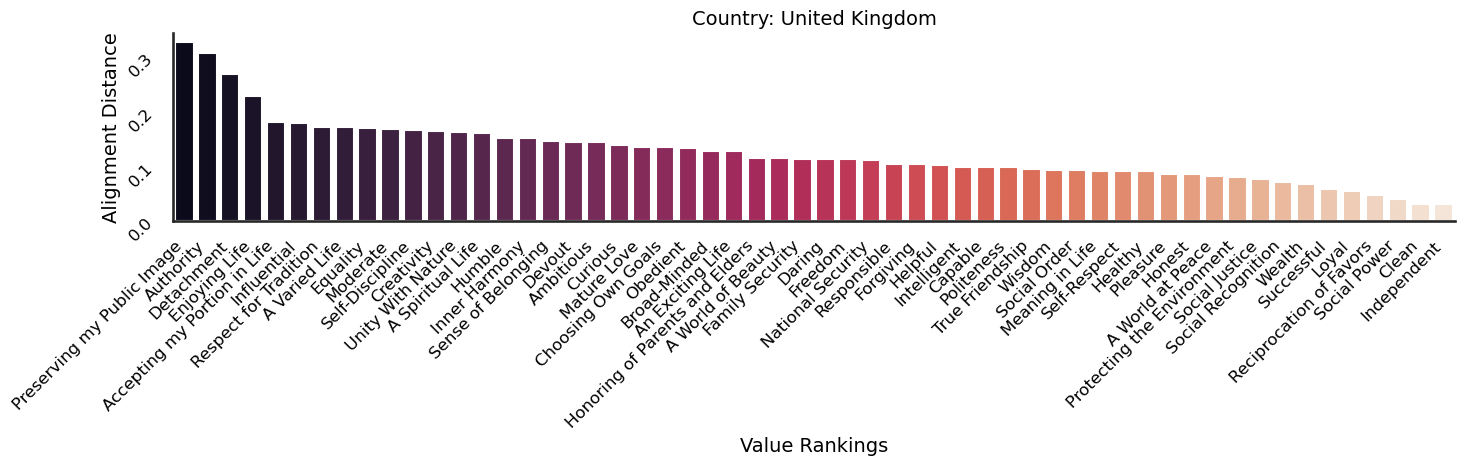

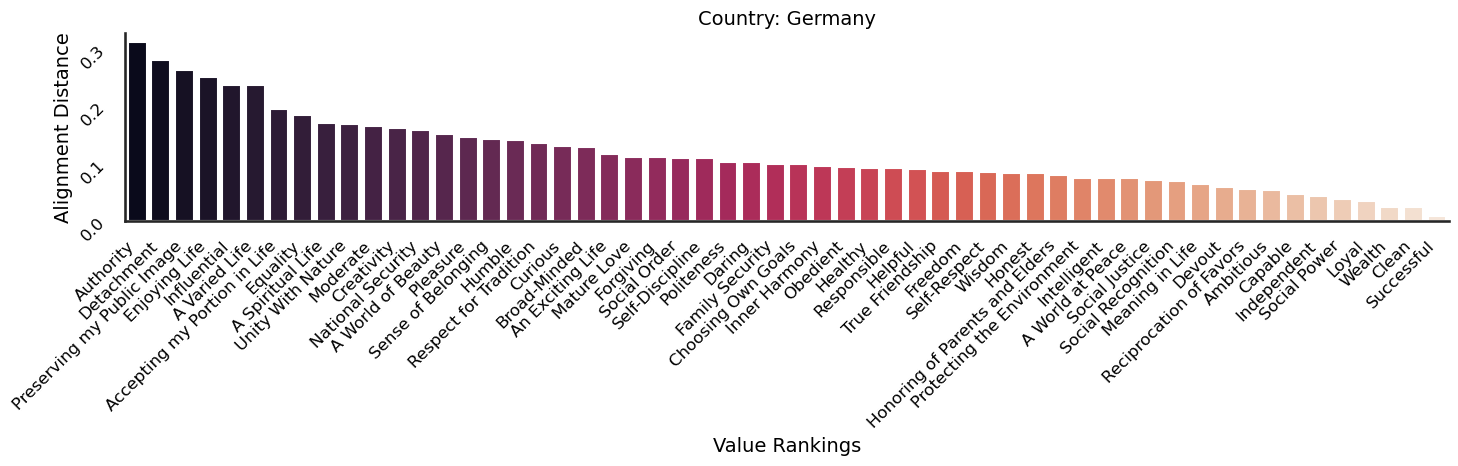

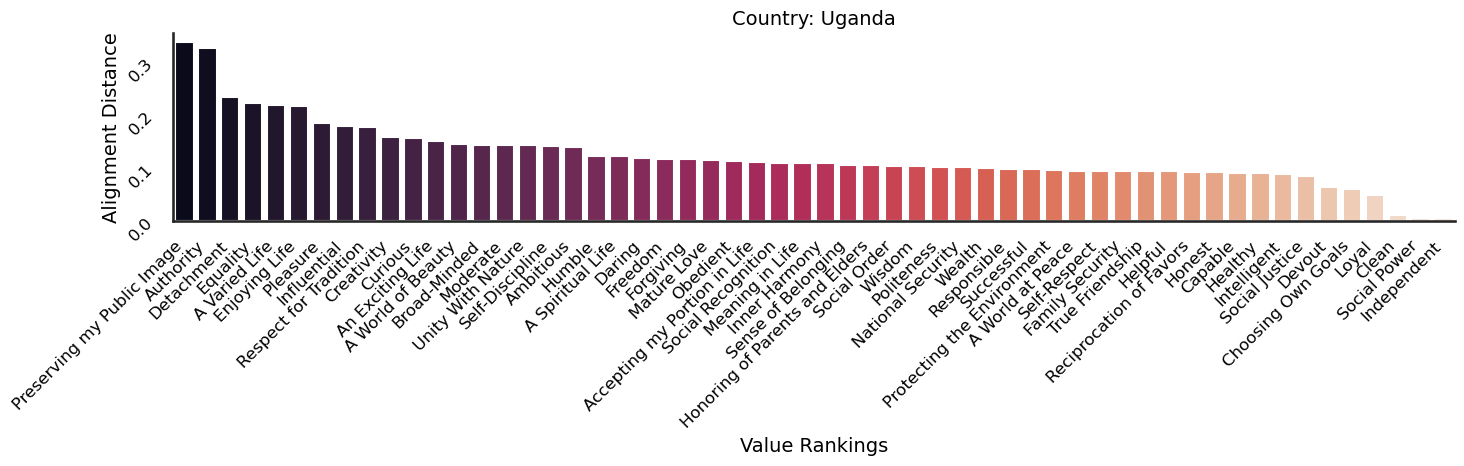

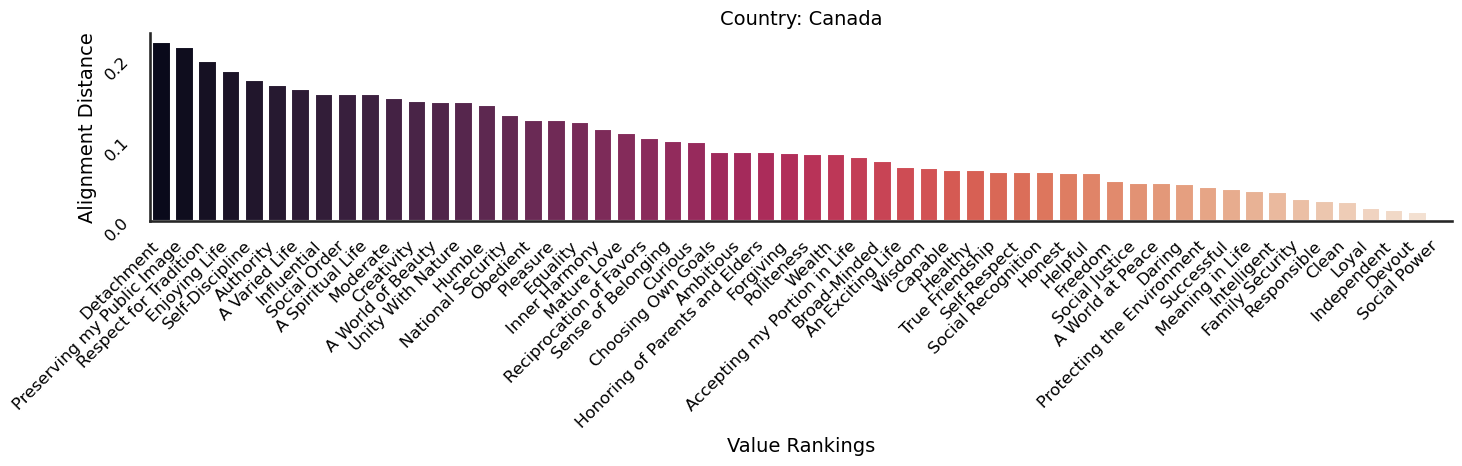

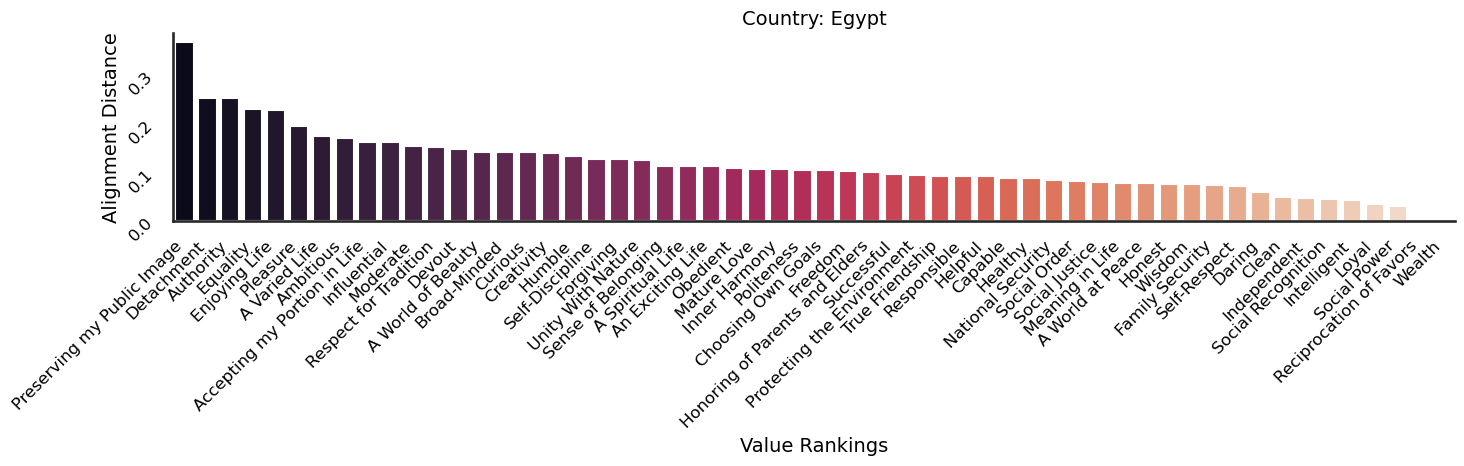

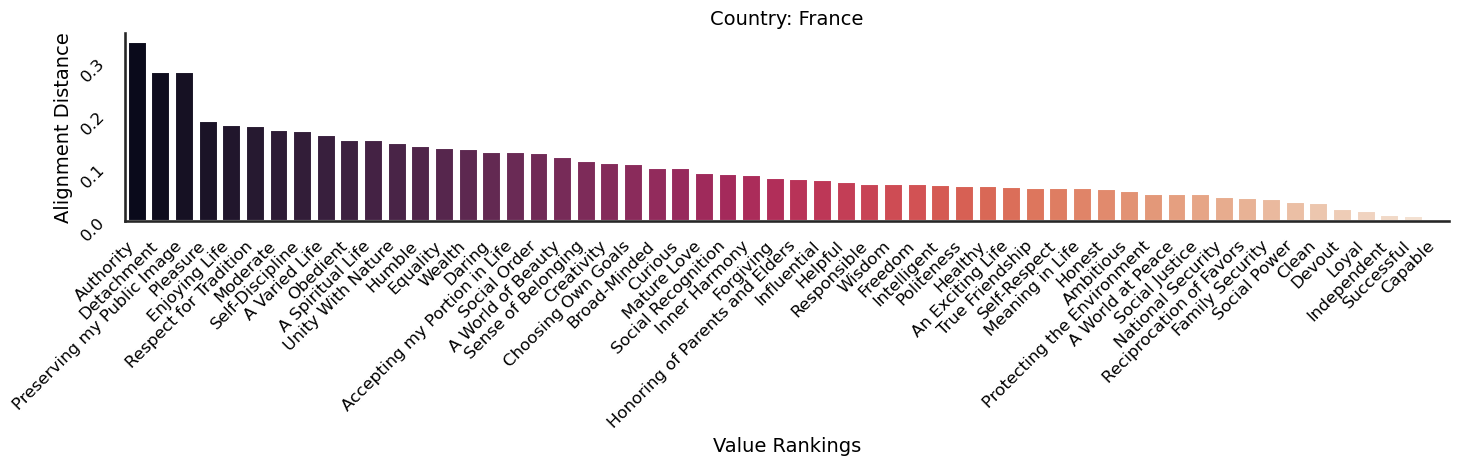

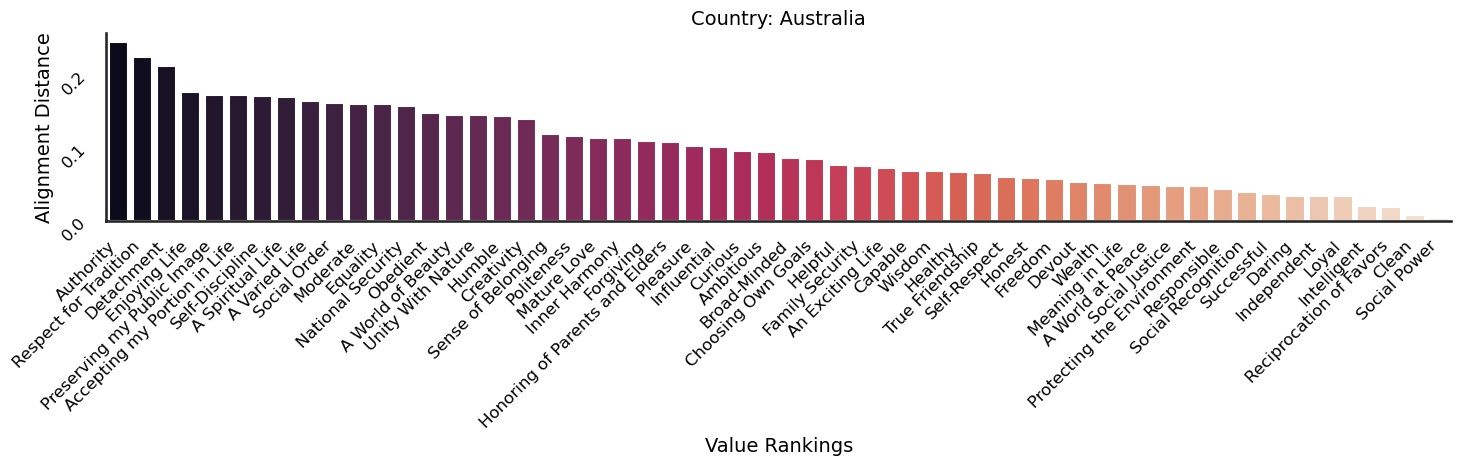

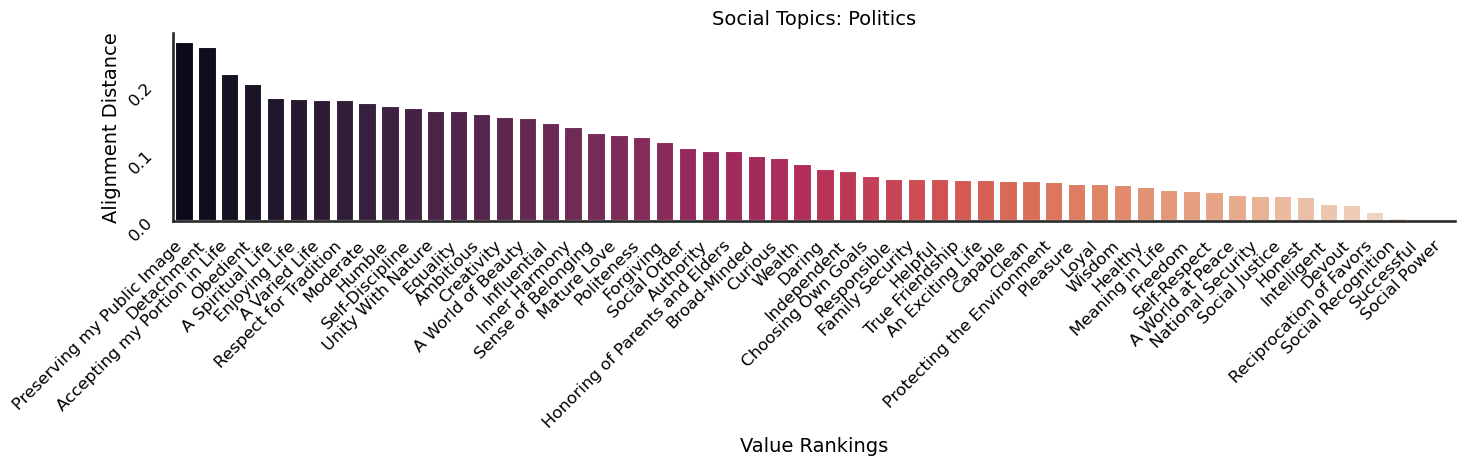

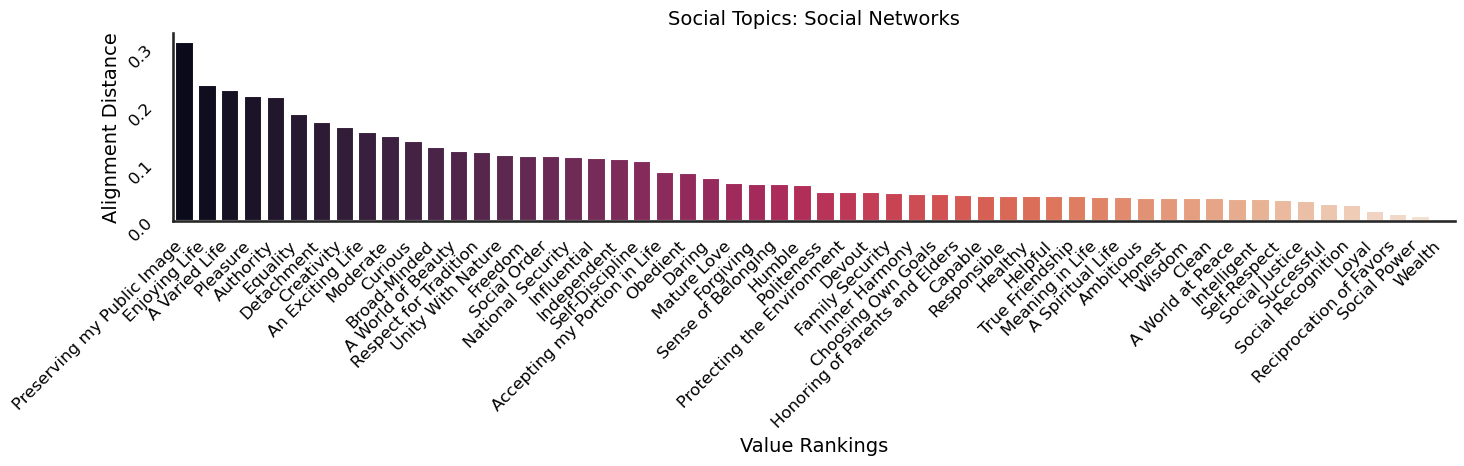

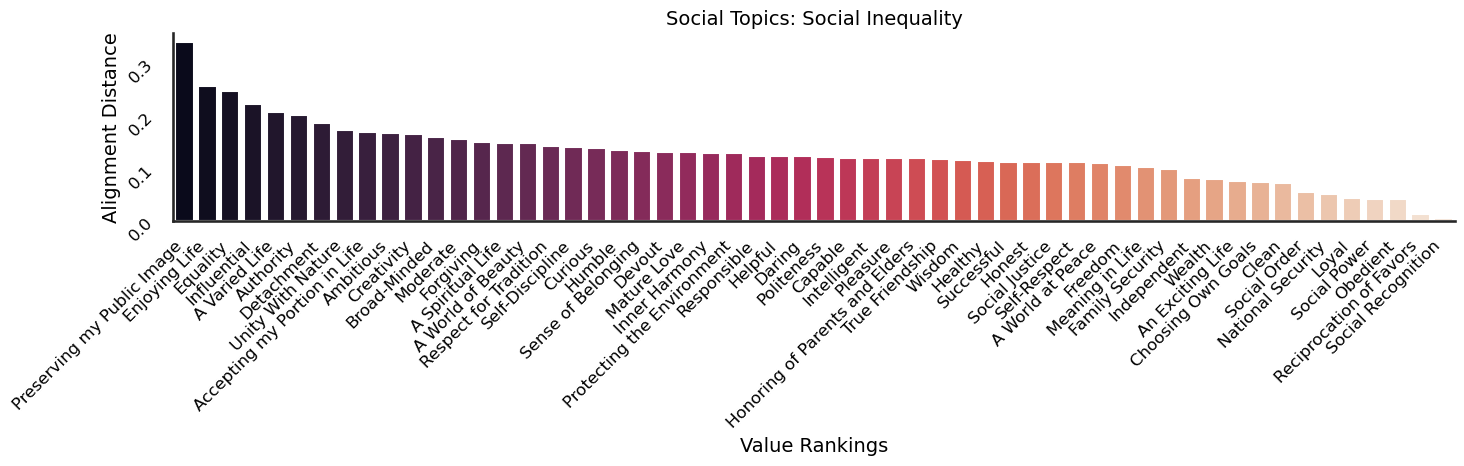

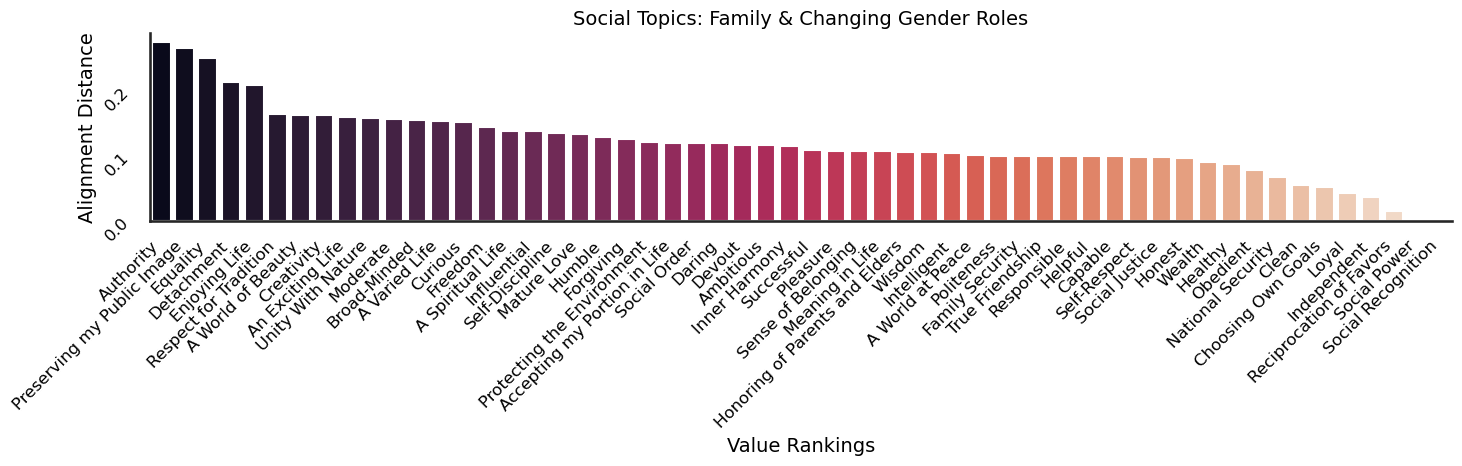

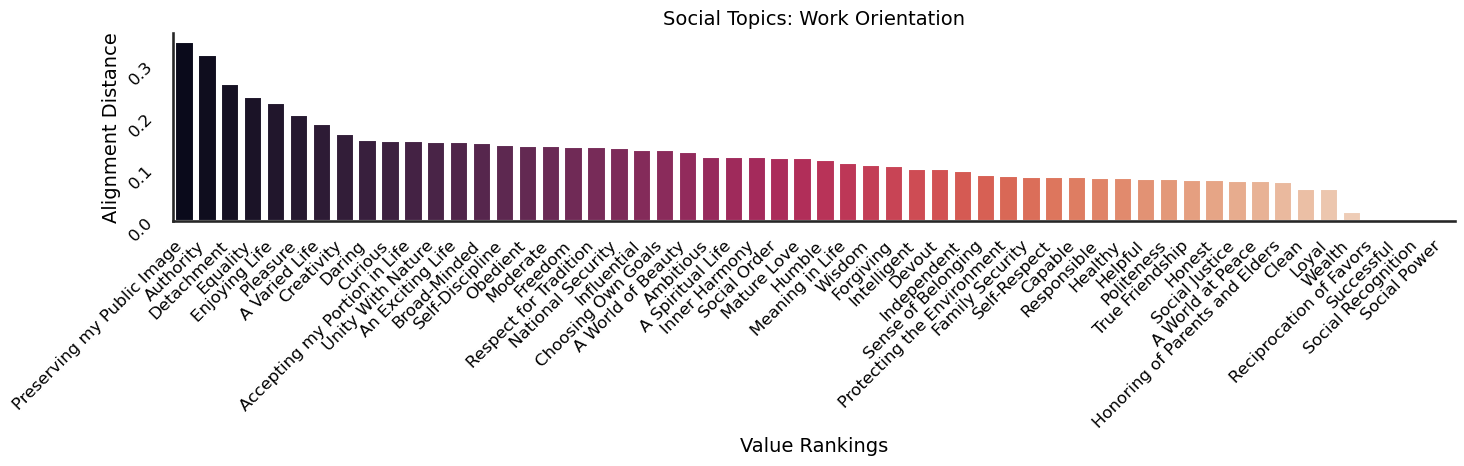

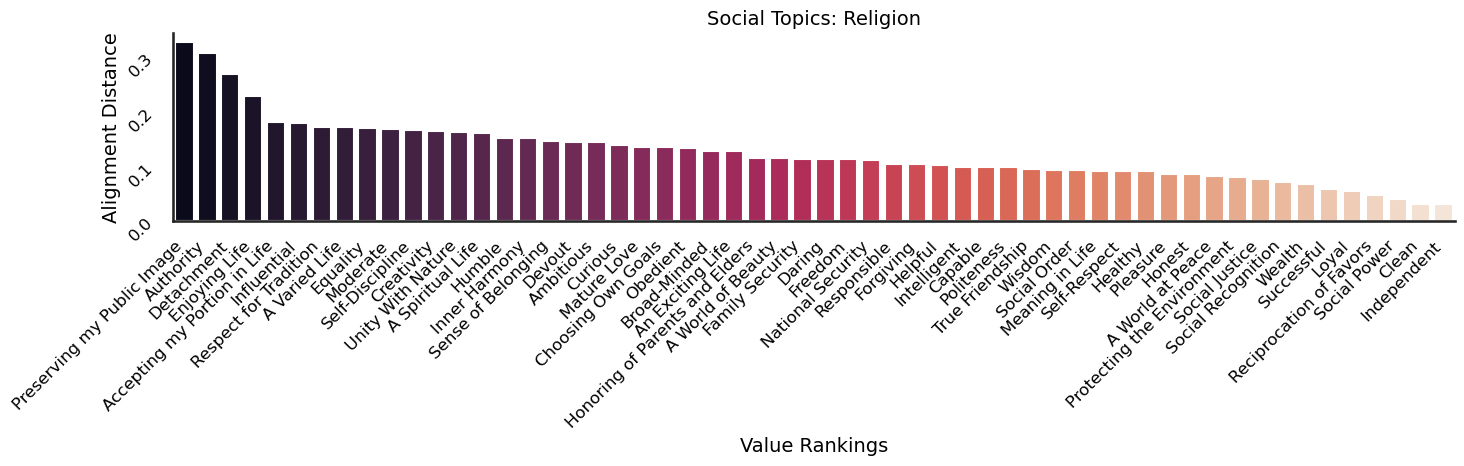

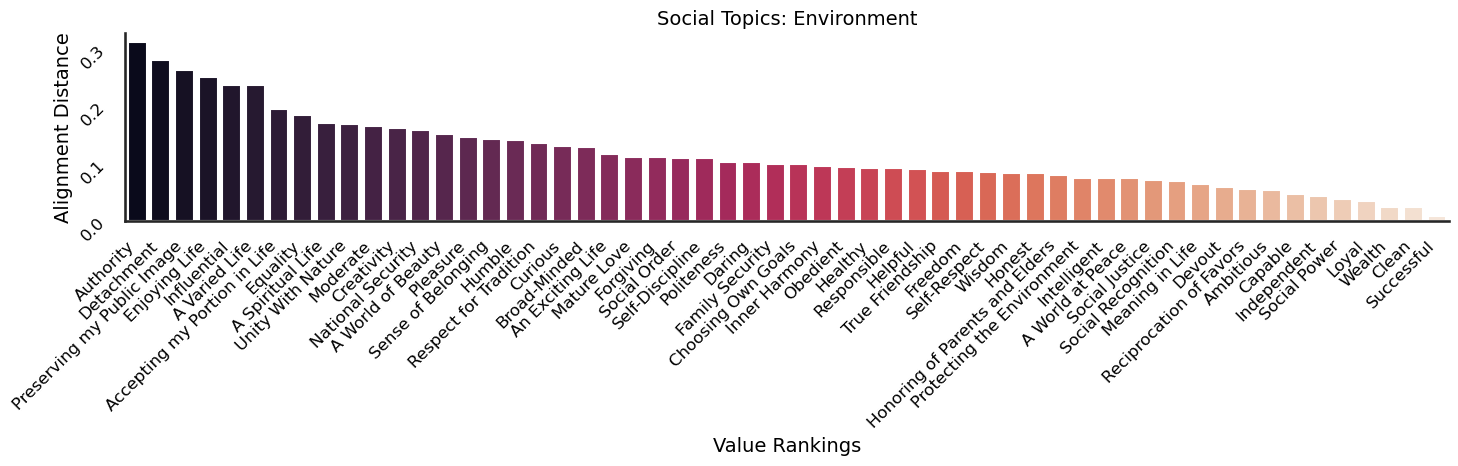

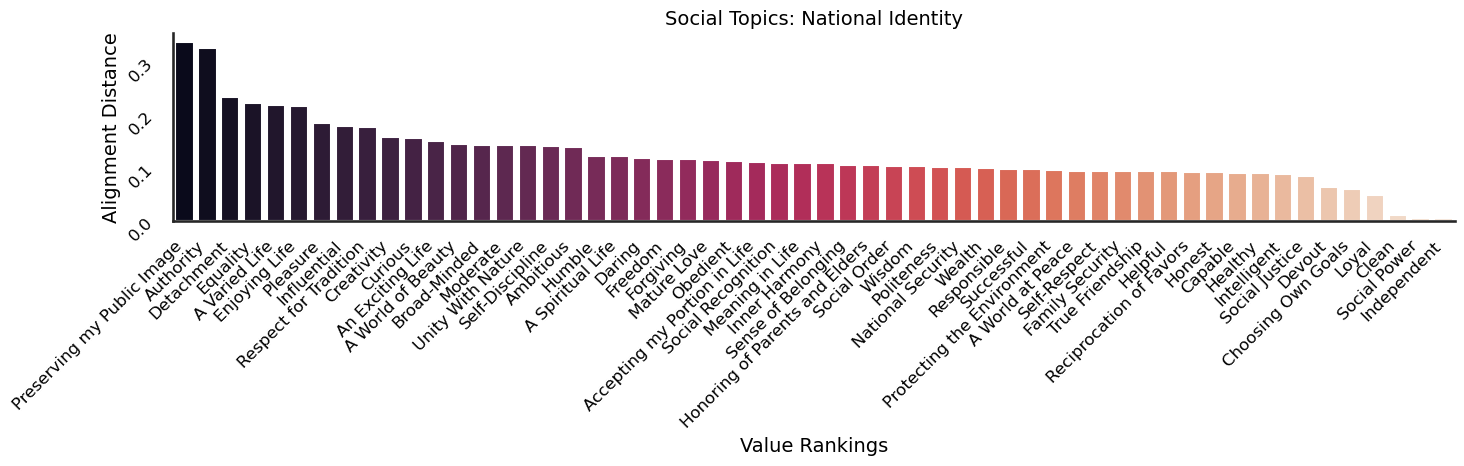

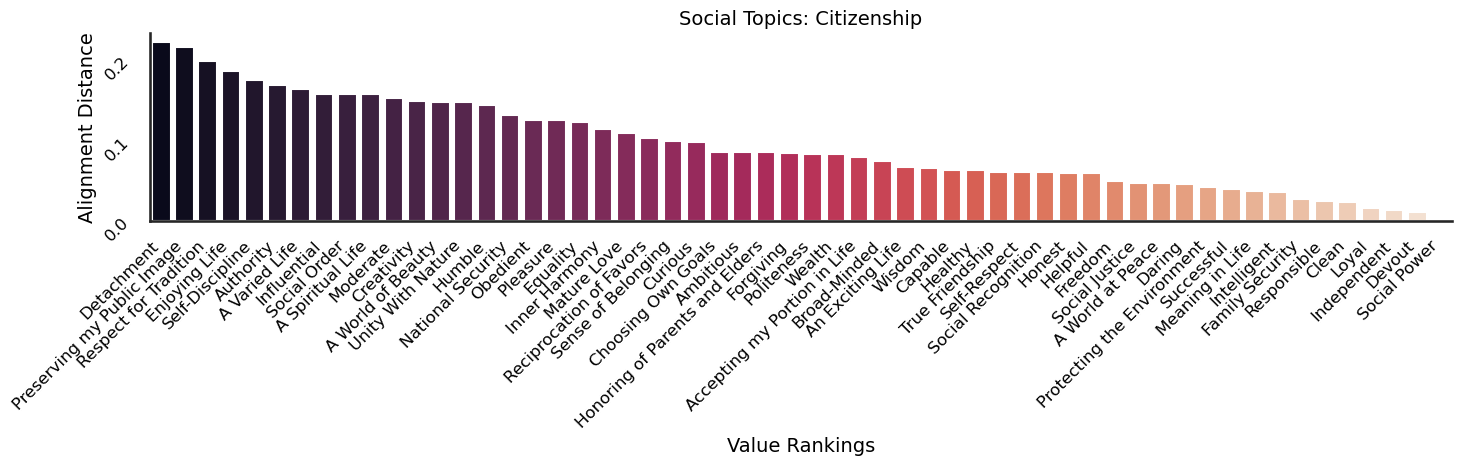

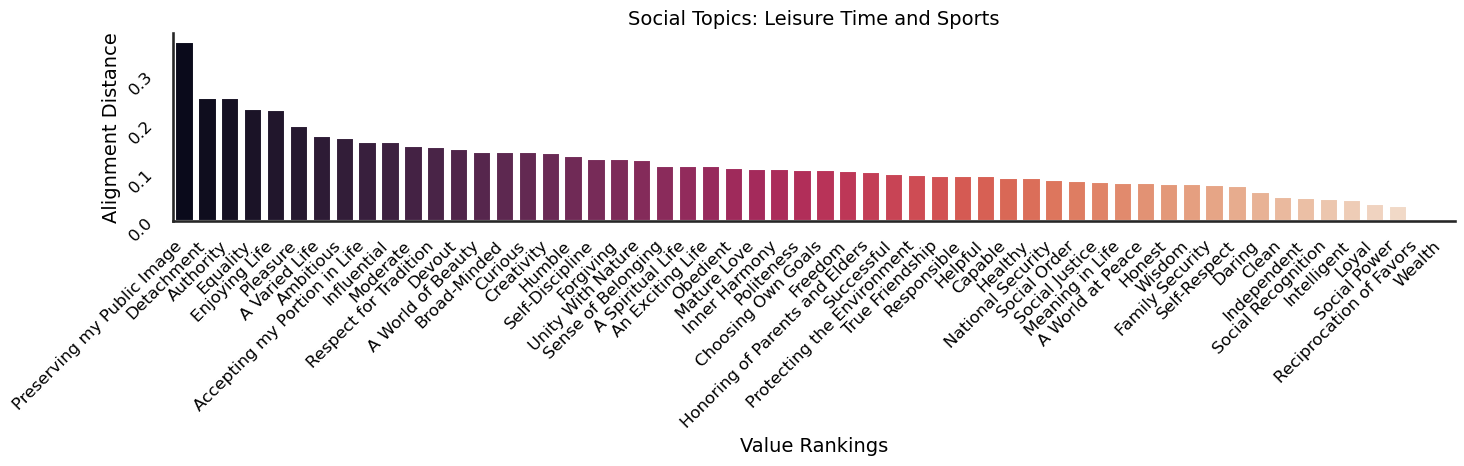

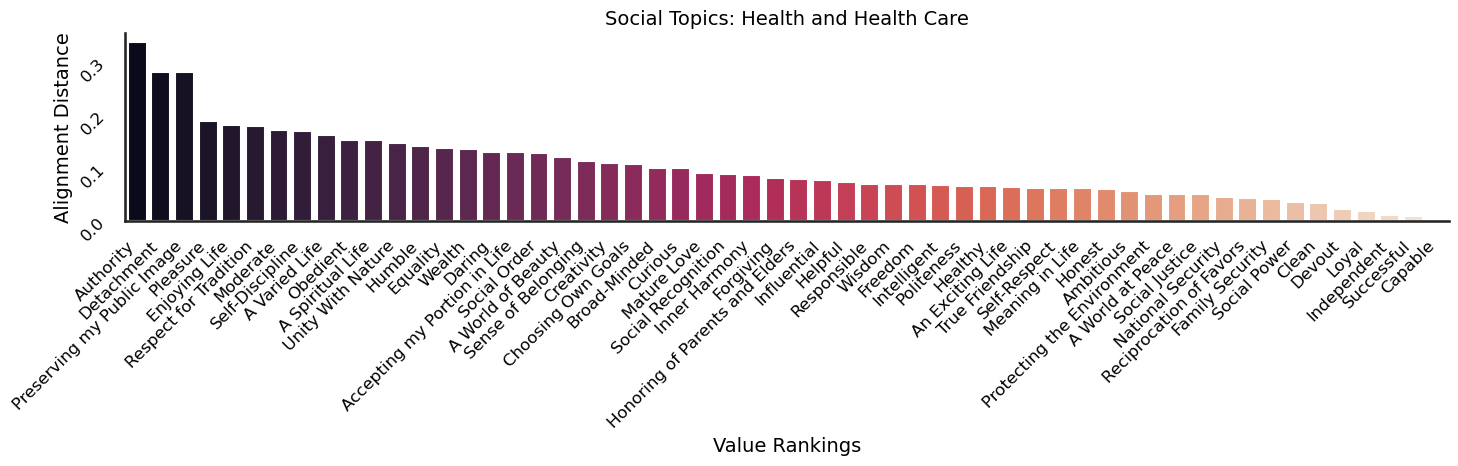

In [40]:
for k in range(len(countries)):
    plot_ranking(ranked_distance_country[k], rank_value_list_country[k], x_label='Value Rankings', y_label='Alignment Distance', title=f"Country: {countries[k]}", saved_path = f"../../../outputs/figures/itcvs/config0_full/ranking_country_{countries[k]}.pdf")

for n in range(len(topics)):
    plot_ranking(ranked_distance_country[n], rank_value_list_country[n], x_label='Value Rankings', y_label='Alignment Distance', title=f"Social Topics: {topics[n]}", saved_path = f"../../../outputs/figures/itcvs/config0_full/ranking_topic_{topics[n]}.pdf")

##### (3) Tables

**Group-wise Alignment Rates**

In [45]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix

def binarize_matrix(matrix: np.array) -> np.array:
    binarized_matrix = np.where(matrix < 0.5, 0., 1.)
    return binarized_matrix
    
def alignment_rate(t1_matrix, t2_matrix):
    t1_matrix = binarize_matrix(t1_matrix).flatten()
    t2_matrix = binarize_matrix(t2_matrix).flatten()
    # print("t1_matrix", t1_matrix)
    # print("t2_matrix", t2_matrix)
    # Invert: 1 - original_value
    # t1_matrix = 1 - t1_matrix
    # t2_matrix = 1 - t2_matrix
    # print("t1_matrix", t1_matrix)
    # print("t2_matrix", t2_matrix)
    # Create the confusion matrix
    cm = confusion_matrix(t1_matrix, t2_matrix)
    # print("cm", cm)
    accuracy = accuracy_score(t1_matrix, t2_matrix)
    precision = precision_score(t1_matrix, t2_matrix)
    recall = recall_score(t1_matrix, t2_matrix)
    f1 = f1_score(t1_matrix, t2_matrix)
    # print("f1", f1)
    # print("precision", precision)
    # print("recall", recall)
    return cm, accuracy, precision, recall, f1


In [46]:
for country in countries:
    sum_f1, sum_acc = [], []
    sum_pre, sum_rec = [], []
    for topic in topics:
        t1_scores = np.array(list(t1_pd[(t1_pd['country'] == country) & (t1_pd['topic'] == topic)].iloc[0,2:]))
        t2_scores = np.array(list(t2_pd[(t1_pd['country'] == country) & (t2_pd['topic'] == topic)].iloc[0,2:]))
        cm, accuracy, precision, recall, f1 = alignment_rate(t1_scores, t2_scores)
        sum_f1.append(f1)
        sum_acc.append(accuracy)
        sum_pre.append(precision)
        sum_rec.append(recall)
    averaged_f1 = np.mean(sum_f1)
    averaged_acc = np.mean(sum_acc)
    averaged_pre = np.mean(sum_pre)
    averaged_rec = np.mean(sum_rec)
    print(f"Country = {country}, f1={averaged_f1}, accuracy= {averaged_acc}, recall={averaged_rec}, precision={averaged_pre}")

Country = United States, f1=0.47668623711404456, accuracy= 0.8701298701298701, recall=0.4542207792207792, precision=0.5272727272727272
Country = India, f1=0.3920110192837466, accuracy= 0.8685064935064936, recall=0.38672438672438675, precision=0.470021645021645
Country = Pakistan, f1=0.4275606194266482, accuracy= 0.827922077922078, recall=0.3670093795093795, precision=0.5414305391578118
Country = Nigeria, f1=0.46021478521478515, accuracy= 0.8814935064935064, recall=0.4292207792207792, precision=0.5314574314574314
Country = Philippines, f1=0.3992343218279048, accuracy= 0.8766233766233765, recall=0.3377804014167651, precision=0.5212121212121212
Country = United Kingdom, f1=0.41389645707827527, accuracy= 0.8327922077922079, recall=0.34976235885326795, precision=0.5393939393939394
Country = Germany, f1=0.3922725940356479, accuracy= 0.8003246753246753, recall=0.3715072805981897, precision=0.4674242424242425
Country = Uganda, f1=0.42487690562556873, accuracy= 0.8603896103896105, recall=0.3477

In [47]:
sum_all_count = []
sum_all_count1 = []
for country in countries:
    sum_f1, sum_acc = [], []
    for topic in topics:
        t1_scores = np.array(list(t1_pd[(t1_pd['country'] == country) & (t1_pd['topic'] == topic)].iloc[0,2:]))
        t2_scores = np.array(list(t2_pd[(t1_pd['country'] == country) & (t2_pd['topic'] == topic)].iloc[0,2:]))
        # print("t1_scores", t1_scores)
        t1_matrix = binarize_matrix(t1_scores).flatten()
        t2_matrix = binarize_matrix(t2_scores).flatten()
        print("len", len(t2_matrix))
        print("t1_matrix", t1_matrix)
        print("t2_matrix", t2_matrix)
        count = np.sum((t1_matrix == 1) & (t2_matrix == 0))
        print("Count where t1_matrix == 1 and t2_matrix == 0:", count)
        count1 = np.sum((t1_matrix == 0) & (t2_matrix == 1))
        print("Count where t1_matrix == 0 and t2_matrix == 1:", count1)
        sum_all_count.append(count)
        sum_all_count1.append(count1)

print("count sum", np.sum(sum_all_count))
print("count1 sum", np.sum(sum_all_count1))

len 56
t1_matrix [1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1.
 0. 0. 0. 0. 0. 0. 0. 0.]
t2_matrix [1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 1. 0. 0.]
Count where t1_matrix == 1 and t2_matrix == 0: 4
Count where t1_matrix == 0 and t2_matrix == 1: 4
len 56
t1_matrix [1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1.
 0. 0. 0. 0. 0. 0. 0. 0.]
t2_matrix [1. 1. 1. 0. 0. 1. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.
 0. 0. 0. 0. 0. 0. 0. 0.]
Count where t1_matrix == 1 and t2_matrix == 0: 3
Count where t1_matrix == 0 and t2_matrix == 1: 4
len 56
t1_matrix [1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

In [48]:
for topic in topics:
    sum_f1, sum_acc = [], []
    for country in countries:
        t1_scores = np.array(list(t1_pd[(t1_pd['country'] == country) & (t1_pd['topic'] == topic)].iloc[0,2:]))
        t2_scores = np.array(list(t2_pd[(t1_pd['country'] == country) & (t2_pd['topic'] == topic)].iloc[0,2:]))
        cm, accuracy, precision, recall, f1 = alignment_rate(t1_scores, t2_scores)
        sum_f1.append(f1)
        sum_acc.append(accuracy)
    averaged_f1 = np.mean(sum_f1)
    averaged_acc = np.mean(sum_acc)
    print(f"topic = {topic}, f1={averaged_f1}, accuracy= {averaged_acc}")

topic = Politics, f1=0.4224370944959181, accuracy= 0.831845238095238
topic = Social Networks, f1=0.4761555982144217, accuracy= 0.8764880952380952
topic = Social Inequality, f1=0.3369941056344565, accuracy= 0.7857142857142856
topic = Family & Changing Gender Roles, f1=0.4500832228773406, accuracy= 0.8616071428571429
topic = Work Orientation, f1=0.4496406371406372, accuracy= 0.8839285714285715
topic = Religion, f1=0.3235433612368597, accuracy= 0.8110119047619047
topic = Environment, f1=0.39428698137138035, accuracy= 0.8288690476190474
topic = National Identity, f1=0.47110528360528353, accuracy= 0.8869047619047619
topic = Citizenship, f1=0.5280409133350309, accuracy= 0.9047619047619048
topic = Leisure Time and Sports, f1=0.4026307119379875, accuracy= 0.8571428571428571
topic = Health and Health Care, f1=0.4953314107919371, accuracy= 0.8616071428571428
